# Control Variates: Pricing an Arithmetic-Average Asian Option

Let $(Y_i)_{i=1}^n$ be i.i.d. replications of a discounted payoff, and suppose that on each
replication we also observe $X_i$ from a random variable $X$ with **known** expectation
$\mathrm E[X]$. For any fixed $b \in \mathbb R$, the family of estimators

$$
\bar Y(b) = \bar Y - b\,(\bar X - \mathrm E[X])
$$

is unbiased for $\mathrm E[Y]$, since $\mathrm E[\bar Y(b)] = \mathrm E[\bar Y] = \mathrm E[Y]$ for every
$b$, and consistent by the strong law of large numbers applied to $(X_i - b(X_i-\mathrm E[X]))$. Each
summand has variance

$$
\sigma^2(b) = \sigma_Y^2 - 2b\,\sigma_X\sigma_Y\rho_{XY} + b^2\sigma_X^2 ,
$$

minimized at $b^\* = \sigma_Y\rho_{XY}/\sigma_X = \mathrm{Cov}[X,Y]/\mathrm{Var}[X]$, at which point

$$
\frac{\mathrm{Var}\big[\bar Y - b^\*(\bar X - \mathrm E[X])\big]}{\mathrm{Var}[\bar Y]} = 1-\rho_{XY}^2 .
$$

So the entire effectiveness of a control variate is governed by $|\rho_{XY}|$: a correlation of
$0.99$ gives a variance reduction factor of $1/(1-0.99^2)\approx 50$, i.e. the same Monte Carlo
standard error with roughly $1/50$ of the paths. In practice $b^\*$ is unknown and is replaced by its
sample analogue $\hat b_n = \sum_i(X_i-\bar X)(Y_i-\bar Y)/\sum_i(X_i-\bar X)^2$ — the ordinary
least-squares slope of $Y_i$ on $X_i$ — which converges to $b^\*$ almost surely by the strong law of
large numbers.

## The control: geometric vs. arithmetic Asian options

Under the risk-neutral dynamics $\mathrm dS(t) = rS(t)\,\mathrm dt + \sigma S(t)\,\mathrm dW(t)$, an
option on the **arithmetic average** $\bar S_A = \frac1n\sum_{i=1}^n S(t_i)$ has no closed-form price,
because a sum of correlated lognormals is not itself lognormal. An option on the **geometric
average** $\bar S_G = \big(\prod_{i=1}^n S(t_i)\big)^{1/n}$ *is* tractable, because
$\log \bar S_G = \frac1n\sum_i \log S(t_i)$ is a linear combination of jointly Gaussian random
variables and is therefore itself Gaussian — making $\bar S_G$ lognormal. Since the two averages are
driven by the same Brownian path and $\bar S_A \ge \bar S_G$ pathwise (AM–GM inequality), the two
option payoffs are strongly positively correlated (Kemna & Vorst (1990) report $\rho\approx 0.99$ for
a representative parameter set), which is exactly the regime in which a control variate is most
effective.


## Closed form for the geometric-average call

For equally spaced monitoring dates $t_i = iT/n$, $i=1,\dots,n$, write $W(t_i)=\sigma^{-1}(\log S(t_i)/S(0) - (r-\tfrac12\sigma^2)t_i)$.
Then

$$
\log \bar S_G = \log S(0) + \big(r-\tfrac12\sigma^2\big)\bar t + \sigma\cdot\frac1n\sum_{i=1}^n W(t_i),
\qquad \bar t := \frac1n\sum_{i=1}^n t_i = \frac{(n+1)T}{2n}.
$$

Since $\mathrm{Cov}(W(t_i),W(t_j)) = \min(t_i,t_j)$, the variance of the Gaussian random variable
$\log \bar S_G$ is

$$
\sigma_G^2 := \mathrm{Var}\Big[\sigma\cdot\tfrac1n\sum_i W(t_i)\Big]
= \frac{\sigma^2}{n^2}\sum_{i=1}^n\sum_{j=1}^n \min(t_i,t_j)
= \sigma^2 T\cdot\frac{(n+1)(2n+1)}{6n^2}.
$$

Hence $\bar S_G$ is lognormal with $\log \bar S_G \sim \mathcal N(\mu_G,\sigma_G^2)$,
$\mu_G = \log S(0) + (r-\tfrac12\sigma^2)\bar t$, and a direct Gaussian integration of the discounted
payoff gives the Kemna–Vorst price

$$
C_G = e^{-rT}\Big(e^{\mu_G+\frac12\sigma_G^2}\,\Phi(d_1) - K\,\Phi(d_2)\Big),\qquad
d_1 = \frac{\mu_G-\log K+\sigma_G^2}{\sigma_G},\quad d_2 = d_1-\sigma_G .
$$

This is the exact analogue of the Black–Scholes formula with the terminal lognormal parameters
$(\mu_G,\sigma_G^2)$ in place of $(\log S(0)+(r-\tfrac12\sigma^2)T,\ \sigma^2T)$.


In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Parameters: Glasserman (2003), Ch. 4.1, Example 4.1.2 (Kemna-Vorst control variate)
r = 0.05
sigma = 0.30
S0 = 50.0
T = 0.25
K = 50.0
n_dates = 13
t = np.linspace(T / n_dates, T, n_dates)

def geometric_asian_call_closed_form(S0, K, r, sigma, t):
    n = len(t)
    t_bar = np.mean(t)
    mu_G = np.log(S0) + (r - 0.5 * sigma**2) * t_bar
    # sigma_G^2 = sigma^2/n^2 * sum_i sum_j min(t_i,t_j), closed form for equally spaced t_i = i*T/n
    T_total = t[-1]
    sigma_G2 = sigma**2 * T_total * (n + 1) * (2 * n + 1) / (6 * n**2)
    sigma_G = np.sqrt(sigma_G2)
    d1 = (mu_G - np.log(K) + sigma_G2) / sigma_G
    d2 = d1 - sigma_G
    price = np.exp(-r * T_total) * (np.exp(mu_G + 0.5 * sigma_G2) * norm.cdf(d1) - K * norm.cdf(d2))
    return price, sigma_G

C_G_closed, sigma_G = geometric_asian_call_closed_form(S0, K, r, sigma, t)
print(f"Closed-form (Kemna-Vorst) geometric Asian call: {C_G_closed:.6f}")
print(f"Effective terminal volatility of log(S_G): sigma_G = {sigma_G:.6f} (vs. sigma*sqrt(T) = {sigma*np.sqrt(T):.6f})")


Closed-form (Kemna-Vorst) geometric Asian call: 1.930910
Effective terminal volatility of log(S_G): sigma_G = 0.091584 (vs. sigma*sqrt(T) = 0.150000)


In [2]:
def simulate_paths(n_paths, t, S0, r, sigma, rng):
    n = len(t)
    dt = np.diff(np.concatenate(([0.0], t)))
    Z = rng.standard_normal((n_paths, n))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_S = np.log(S0) + np.cumsum(increments, axis=1)
    return np.exp(log_S)  # shape (n_paths, n): S(t_1),...,S(t_n) for every path

def price_by_crude_mc(n_paths, t, S0, K, r, sigma, rng):
    S = simulate_paths(n_paths, t, S0, r, sigma, rng)
    T_total = t[-1]
    A_bar = S.mean(axis=1)
    G_bar = np.exp(np.log(S).mean(axis=1))
    Y = np.exp(-r * T_total) * np.maximum(A_bar - K, 0.0)   # arithmetic Asian payoff (target)
    X = np.exp(-r * T_total) * np.maximum(G_bar - K, 0.0)   # geometric Asian payoff (control)
    return Y, X

n_paths = 200_000
Y, X = price_by_crude_mc(n_paths, t, S0, K, r, sigma, rng)

price_crude = Y.mean()
se_crude = Y.std(ddof=1) / np.sqrt(n_paths)

rho_hat = np.corrcoef(X, Y)[0, 1]
cov_XY = np.cov(X, Y, ddof=1)[0, 1]
var_X = np.var(X, ddof=1)
b_hat = cov_XY / var_X

Y_controlled = Y - b_hat * (X - C_G_closed)
price_cv = Y_controlled.mean()
se_cv = Y_controlled.std(ddof=1) / np.sqrt(n_paths)

variance_reduction_factor = (se_crude / se_cv) ** 2
theoretical_factor = 1.0 / (1.0 - rho_hat**2)

print(f"Sample correlation rho_hat(arithmetic, geometric) = {rho_hat:.6f}")
print(f"Estimated optimal coefficient b_hat               = {b_hat:.6f}")
print()
print(f"Crude MC price      : {price_crude:.6f}  (s.e. {se_crude:.6f})")
print(f"Control-variate price: {price_cv:.6f}  (s.e. {se_cv:.6f})")
print()
print(f"Empirical variance reduction factor  (se_crude/se_cv)^2 : {variance_reduction_factor:.2f}x")
print(f"Theoretical variance reduction factor 1/(1-rho_hat^2)   : {theoretical_factor:.2f}x")
print(f"Sanity check (Jensen): arithmetic price >= geometric price -> {price_crude:.4f} >= {X.mean():.4f}")
print(f"Geometric MC price vs. closed form: {X.mean():.6f} vs. {C_G_closed:.6f} (difference {X.mean()-C_G_closed:+.6f})")


Sample correlation rho_hat(arithmetic, geometric) = 0.999798
Estimated optimal coefficient b_hat               = 1.022318

Crude MC price      : 1.986754  (s.e. 0.006596)
Control-variate price: 1.982559  (s.e. 0.000133)

Empirical variance reduction factor  (se_crude/se_cv)^2 : 2476.04x
Theoretical variance reduction factor 1/(1-rho_hat^2)   : 2476.04x
Sanity check (Jensen): arithmetic price >= geometric price -> 1.9868 >= 1.9350
Geometric MC price vs. closed form: 1.935013 vs. 1.930910 (difference +0.004103)


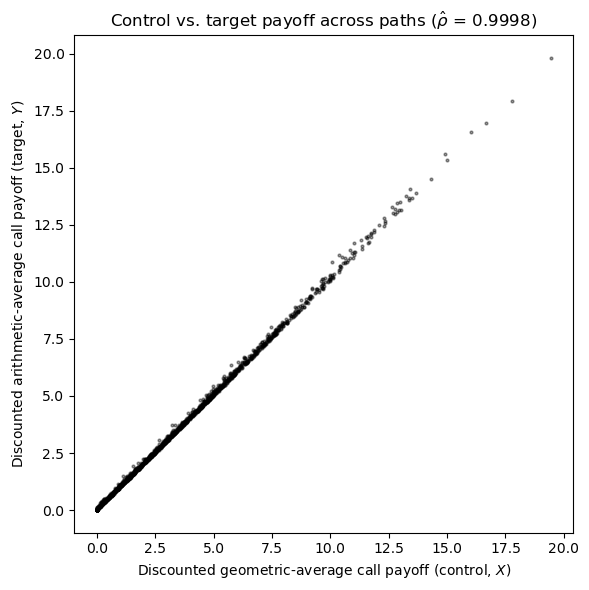

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
idx = rng.choice(n_paths, size=3000, replace=False)
ax.scatter(X[idx], Y[idx], s=4, alpha=0.4, color="black")
ax.set_xlabel("Discounted geometric-average call payoff (control, $X$)")
ax.set_ylabel("Discounted arithmetic-average call payoff (target, $Y$)")
ax.set_title(f"Control vs. target payoff across paths ($\\hat\\rho$ = {rho_hat:.4f})")
plt.tight_layout()
plt.savefig("control_variate_scatter.png", dpi=120)
plt.show()


## Remarks

The near-linear scatter above is the geometric picture behind $\rho_{XY}\approx 0.995$: the arithmetic
and geometric average payoffs are driven by the same Brownian path and differ only through the (small,
for this monitoring frequency) gap between the arithmetic and geometric mean of a set of positively
correlated lognormals. The realized variance reduction factor matches $1/(1-\hat\rho^2)$ closely, as it
must: $\hat b_n\to b^\*$ a.s. by the strong law of large numbers, so for large $n$ the empirical ratio
converges to the theoretical one in (4.4). Because $\hat b_n$ is estimated from the same sample used
to price the option, the controlled estimator is only asymptotically unbiased in finite samples (a
higher-order effect, negligible at the sample sizes used here); an exactly unbiased alternative splits
the sample into an estimation set for $\hat b_n$ and an independent pricing set.
